# ACTIVIDAD 4: Modelos alternativos


**Equipo 61**

Alumnos:

Gustavo Adolfo Morales García A00828432

Alejandro Jesús Mondragón Jiménez A01795837

Sebastián Ezequiel Coronado Rivera A01212824



### Objetivo

Este cuarto avance tiene como objetivo explorar una gama diversa de algoritmos y arquitecturas de aprendizaje automático con el fin de identificar el modelo de mejor desempeño para inferir `LogMass` de galaxias a partir de imágenes astronómicas. Partiendo del modelo CNN custom del Avance 3 (R² ≈ 0.79, MAE ≈ 0.3367 dex) como referencia, se construyen y comparan **7 modelos individuales** (no ensambles) con algoritmos variados.

**Estrategia de exploración:**

| # | Modelo | Tipo de algoritmo |
|---|--------|------------------|
| 0 | CNN Custom (Avance 3) | Referencia |
| 1 | CNN Custom + GridSearch | Desde cero – ajuste de HPs del baseline |
| 2 | ResNet-like Custom | Desde cero – bloques residuales |
| 3 | EfficientNetB0 | Transfer Learning |
| 4 | MobileNetV2 | Transfer Learning |
| 5 | VGG16 | Transfer Learning |
| 6 | Vision Transformer (ViT) | Arquitectura basada en atención |
| 7 | CNN + Metadata (Multimodal) | Fusión imagen + variables tabulares |

Los dos mejores modelos son ajustados y se selecciona el modelo final.

---

In [2]:
# Importación de librerías necesarias
from pathlib import Path
import pandas as pd  # Manipulación y análisis de datos
import numpy as np  # Operaciones numéricas y arrays
import matplotlib.pyplot as plt  # Visualización básica
import seaborn as sns  # Visualización estadística avanzada
from scipy import stats  # Funciones estadísticas
from scipy.stats import skew, kurtosis  # Métricas de distribución
import warnings  # Manejo de advertencias
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Configuración de estilos y opciones
warnings.filterwarnings('ignore')  # Ignorar advertencias para limpieza visual
sns.set_style('whitegrid')  # Estilo de gráficas con cuadrícula blanca
plt.rcParams['figure.figsize'] = (12, 6)  # Tamaño por defecto de figuras
plt.rcParams['font.size'] = 10  # Tamaño de fuente
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.precision', 4)  # Precisión decimal en display

In [3]:
#Leer archivo con datos originales
df = pd.read_csv("inferencia.csv")

#Copia de dataset
df_clean = df.copy()

#REEMPLAZAR PLACEHOLDERS POR NaN
placeholder_map = {
    "C": [-999],
    "A": [-999],
    "S": [-999, -102.97, -118.68],
    "nsa_sersic_mass": [-9999],
    "nsa_sersic_ba": [-9999],
    "nsa_sersic_n": [-9999]
}

for col, values in placeholder_map.items():
    df_clean[col] = df_clean[col].replace(values, np.nan)

#DEFINICIÓN DE VARIABLES
# Variables con asimetría fuerte o potencialmente problemáticas
skewed_cols = [
    "nsa_sersic_mass",
    "PETRO_TH90",
    "modelMag_r",
    "C",
    "A",
    "S"
]

# Variables que ya están bastante estabilizadas o en log
normal_cols = [
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re"
]

# Coordenadas
coordinate_cols = [
    "objra",
    "objdec"
]

#Orden original de las columnas
final_columns = [
    "objra",
    "objdec",
    "C",
    "A",
    "S",
    "nsa_sersic_mass",
    "LogMass",
    "nsa_sersic_ba",
    "nsa_sersic_n",
    "PETRO_TH90",
    "log_age_mean_LW",
    "log_ZH_mean_LW",
    "log_SFR_ssp",
    "log_SFR_Ha",
    "vel_sigma_Re",
    "modelMag_r"
]

# Filtrar solo columnas existentes
skewed_cols = [c for c in skewed_cols if c in df_clean.columns]
normal_cols = [c for c in normal_cols if c in df_clean.columns]
coordinate_cols = [c for c in coordinate_cols if c in df_clean.columns]

In [4]:
# Para variables sesgadas: imputación + Yeo-Johnson + escalado
skewed_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("yeojohnson", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler())
])

# Para variables ya estables: imputación + escalado
normal_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Para coordenadas: imputación + escalado
coordinate_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# COLUMN TRANSFORMER
preprocessor = ColumnTransformer([
    ("skewed_vars", skewed_pipeline, skewed_cols),
    ("normal_vars", normal_pipeline, normal_cols),
    ("coordinates", coordinate_pipeline, coordinate_cols)
], remainder="drop")

# AJUSTAR Y TRANSFORMAR
X_transformed = preprocessor.fit_transform(df_clean)

transformer_columns = skewed_cols + normal_cols + coordinate_cols

df_transformed_numeric = pd.DataFrame(
    X_transformed,
    columns=transformer_columns,
    index=df_clean.index
)

# Reordenar columnas al formato deseado
df_transformed_numeric = df_transformed_numeric[final_columns]

# Conservar columna name como identificador de cada galaxia
df_transformed = pd.concat(
    [
        df_clean[["name"]],
        df_transformed_numeric
    ],
    axis=1
)

print("Shape original:", df_clean.shape)
print("Shape transformado:", df_transformed.shape)
df_transformed.head()

Shape original: (10126, 17)
Shape transformado: (10126, 17)


,name,objra,objdec,C,A,S,nsa_sersic_mass,LogMass,nsa_sersic_ba,nsa_sersic_n,PETRO_TH90,log_age_mean_LW,log_ZH_mean_LW,log_SFR_ssp,log_SFR_Ha,vel_sigma_Re,modelMag_r
0,manga-10001-12701,-0.6523,1.6126,-1.3471,-0.0074,-0.0309,-0.9490,-0.9403,-1.2084,-1.2748,-0.9719,-1.1521,-1.3084,0.8322,0.6072,2.0522,0.8076
1,manga-10001-12702,-0.6482,1.6060,-0.6744,-0.3508,-0.2956,-0.6325,-0.6049,-0.4241,-0.9179,0.1545,-1.0850,-0.7010,0.5290,0.1930,2.0572,1.0683
2,manga-10001-12703,-0.6176,1.5844,-0.0944,-0.2080,0.1655,-0.0753,-0.0354,-1.7963,-0.5420,-0.0049,-0.7376,-0.1556,0.7577,0.7587,0.6348,0.1766
3,manga-10001-12704,-0.6442,1.6170,0.1224,0.0694,0.7020,-0.7591,-0.7380,-2.0492,-1.2099,1.4307,-0.7461,-0.7883,-0.0408,0.3075,0.7127,-0.8335
4,manga-10001-12705,-0.6080,1.6044,-0.6729,-0.1478,-0.1510,-0.1074,-0.0674,-0.5909,-1.0158,-0.3170,-1.1710,-1.2657,1.0966,1.0637,1.9645,0.1993


In [5]:
# Importaciones adicionales para deep learning y búsqueda de hiperparámetros
import time
import itertools
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0, VGG16, MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Keras Tuner para búsqueda de hiperparámetros (GridSearch)
try:
    import keras_tuner as kt
    KERAS_TUNER_AVAILABLE = True
    print("keras-tuner disponible.")
except ImportError:
    KERAS_TUNER_AVAILABLE = False
    print("keras-tuner no instalado. Instalar con: pip install keras-tuner")
    print("Las celdas de GridSearch usarán busqueda manual como fallback.")

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPUs disponibles: {tf.config.list_physical_devices('GPU')}") 

keras-tuner no instalado. Instalar con: pip install keras-tuner
Las celdas de GridSearch usarán busqueda manual como fallback.
TensorFlow: 2.21.0
GPUs disponibles: []


In [6]:

# CONSTRUCCIÓN DEL DATASET SUPERVISADO PARA LogMass
# Relación imagen <-> variable objetivo mediante 'name'


target_col = "LogMass"

df_logmass = df_transformed[["name", target_col]].copy()
df_logmass = df_logmass.dropna(subset=[target_col])

# Ajustar ruta según entorno local
image_dir = Path(r"/Users/gustavomorales/Desktop/ITESM_MNA/Proyecto integrador/Imagenes")

df_logmass["image_path"]   = df_logmass["name"].apply(lambda x: image_dir / f"{x}.jpg")
df_logmass["image_exists"] = df_logmass["image_path"].apply(lambda p: p.exists())

print("Total registros:      ", len(df_logmass))
print("Imagenes encontradas: ", df_logmass["image_exists"].sum())
print("Imagenes faltantes:   ", (~df_logmass["image_exists"]).sum())

df_logmass = df_logmass[df_logmass["image_exists"]].copy()
df_logmass = df_logmass[["name", target_col, "image_path"]].copy()


# TRAIN / VALIDATION / TEST SPLIT
# 70% entrenamiento | 15% validacion | 15% prueba
# Misma semilla que Avance 3 para comparabilidad

train_df, temp_df = train_test_split(df_logmass, test_size=0.30, random_state=42)
val_df,   test_df = train_test_split(temp_df,    test_size=0.50, random_state=42)

print("\nShape dataset LogMass:", df_logmass.shape)
print("Train:     ", train_df.shape)
print("Validation:", val_df.shape)
print("Test:      ", test_df.shape)

Total registros:       10126
Imagenes encontradas:  10126
Imagenes faltantes:    0

Shape dataset LogMass: (10126, 3)
Train:      (7088, 3)
Validation: (1519, 3)
Test:       (1519, 3)


In [7]:

# PARAMETROS GLOBALES Y FUNCIONES DE CARGA DE IMAGENES


IMG_SIZE   = (224, 224)   # Compatible con todos los modelos
BATCH_SIZE = 16           # Consistente con Avance 3

def load_image_regression(image_path, target):
    """
    Carga, decodifica, redimensiona y normaliza una imagen JPEG.

    Parameters
    ----------
    image_path : tf.string
    target     : tf.float32  valor objetivo normalizado (LogMass)

    Returns
    -------
    image  : tf.Tensor shape (224, 224, 3) float32, valores en [0, 1]
    target : tf.float32
    """
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return image, target


def create_dataset(dataframe, shuffle=True):
    """
    Construye un tf.data.Dataset desde un DataFrame con rutas de imagenes.

    Parameters
    ----------
    dataframe : pd.DataFrame  columnas 'image_path' y target_col
    shuffle   : bool

    Returns
    -------
    dataset : tf.data.Dataset
    """
    image_paths = dataframe["image_path"].astype(str).values
    targets     = dataframe[target_col].astype("float32").values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    dataset = dataset.map(load_image_regression, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=42)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = create_dataset(train_df, shuffle=True)
val_ds   = create_dataset(val_df,   shuffle=False)
test_ds  = create_dataset(test_df,  shuffle=False)

print("Datasets creados exitosamente.")

Datasets creados exitosamente.


---
## Funciones utilitarias compartidas

Se definen aquí las funciones de evaluación, entrenamiento y visualización
que se reutilizan en todos los modelos del avance.

In [8]:

# evaluate_regression_complete
# Heredada del Avance 3; calcula MAE, RMSE, R2, Scatter, Bias


def evaluate_regression_complete(y_true, y_pred, variable_name='LogMass'):
    """
    Evalua un modelo de regresion con metricas astronomicas completas.

    Parameters
    ----------
    y_true        : array-like  valores reales
    y_pred        : array-like  valores predichos
    variable_name : str

    Returns
    -------
    dict : R2, MAE, RMSE, MSE, Scatter, Bias, RMSE_MAE_ratio, Categoria
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mae      = mean_absolute_error(y_true, y_pred)
    mse      = mean_squared_error(y_true, y_pred)
    rmse     = np.sqrt(mse)
    r2       = r2_score(y_true, y_pred)
    residuals = y_true - y_pred
    scatter   = np.std(residuals)
    bias      = np.mean(residuals)
    rmse_mae  = rmse / mae if mae > 0 else np.inf

    print(f"Metricas de Regresion para {variable_name}:")
    print(f"  R2 Score:        {r2:.4f}  ({r2*100:.2f}% varianza explicada)")
    print(f"  MAE:             {mae:.4f} dex")
    print(f"  RMSE:            {rmse:.4f} dex")
    print(f"  MSE:             {mse:.4f} dex2")
    print(f"  Scatter (sigma): {scatter:.4f} dex")
    print(f"  Bias:            {bias:+.4f} dex")
    print(f"  RMSE/MAE ratio:  {rmse_mae:.2f}")
    print()

    mae_f = 10 ** mae; scat_f = 10 ** scatter
    print("Interpretacion fisica (escala lineal):")
    print(f"  Error promedio (MAE):   {mae_f:.2f}x")
    print(f"  Dispersion tipica:      +/-{scat_f:.2f}x")
    print(f"  Rango de error tipico:  [{1/mae_f:.2f}x, {mae_f:.2f}x]")
    if   abs(bias) < 0.05: print("  Sin sesgo sistematico significativo (bias ~ 0)")
    elif bias > 0:         print(f"  Sesgo positivo: modelo subestima ({bias:+.4f} dex)")
    else:                  print(f"  Sesgo negativo: modelo sobreestima ({bias:+.4f} dex)")
    print()

    if   r2 >= 0.90: cat, desc = "EXCELENTE", "Modelo de alta precision"
    elif r2 >= 0.80: cat, desc = "MUY BUENO", "Baseline fuerte"
    elif r2 >= 0.70: cat, desc = "BUENO",     "Desempeno aceptable"
    elif r2 >= 0.50: cat, desc = "REGULAR",   "Mejora requerida"
    else:            cat, desc = "INACEPTABLE","Modelo no viable"

    print(f"Evaluacion cualitativa: {cat} - {desc}")
    print()
    print("Diagnostico de errores:")
    if   rmse_mae > 2.0: print(f"  ADVERTENCIA: RMSE/MAE={rmse_mae:.2f} - outliers severos")
    elif rmse_mae > 1.5: print(f"  NOTA: RMSE/MAE={rmse_mae:.2f} - algunos errores grandes")
    else:                print(f"  RMSE/MAE={rmse_mae:.2f} - distribucion normal, sin outliers extremos")

    return {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'MSE': mse,
            'Scatter': scatter, 'Bias': bias,
            'RMSE_MAE_ratio': rmse_mae, 'Categoria': cat}



# Funciones auxiliares de entrenamiento y visualizacion


def get_predictions(model, dataset):
    """Obtiene predicciones y etiquetas reales de un tf.data.Dataset."""
    y_true_list, y_pred_list = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true_list.extend(labels.numpy())
        y_pred_list.extend(preds.flatten())
    return np.array(y_true_list), np.array(y_pred_list)


def train_model(model, train_ds, val_ds, epochs=30, patience=7):
    """
    Entrena un modelo Keras con EarlyStopping y ReduceLROnPlateau.

    Parameters
    ----------
    model    : tf.keras.Model  (ya compilado)
    train_ds, val_ds : tf.data.Dataset
    epochs   : int
    patience : int  paciencia EarlyStopping

    Returns
    -------
    history : tf.keras.callbacks.History
    elapsed : float  segundos totales
    """
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]
    start   = time.time()
    history = model.fit(train_ds, validation_data=val_ds,
                        epochs=epochs, callbacks=callbacks, verbose=1)
    elapsed = time.time() - start
    print(f"\nTiempo de entrenamiento: {elapsed:.1f}s ({elapsed/60:.1f} min)")
    return history, elapsed


def plot_training_curves(history, model_name):
    """Grafica curvas de perdida (MSE) y MAE de entrenamiento/validacion."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss', lw=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',   lw=2)
    axes[0].set_title(f'Curva de Perdida (MSE) - {model_name}')
    axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('MSE')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['mae'],     label='Train MAE', lw=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE',   lw=2)
    axes[1].set_title(f'Curva de MAE - {model_name}')
    axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('MAE (dex)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_combined_history(h1, h2, model_name):
    """
    Grafica curvas de dos fases de entrenamiento (feature extraction + fine-tuning)
    unificadas con linea vertical separadora.
    Retorna el total de epocas ejecutadas.
    """
    sep   = len(h1.history['loss'])
    loss  = h1.history['loss']     + h2.history['loss']
    vloss = h1.history['val_loss'] + h2.history['val_loss']
    mae   = h1.history['mae']      + h2.history['mae']
    vmae  = h1.history['val_mae']  + h2.history['val_mae']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, y, yv, ylabel, title in [
        (axes[0], loss, vloss, 'MSE',       f'Curva de Perdida - {model_name}'),
        (axes[1], mae,  vmae,  'MAE (dex)', f'Curva de MAE - {model_name}')
    ]:
        ax.plot(y,  label='Train', lw=2)
        ax.plot(yv, label='Val',   lw=2)
        ax.axvline(x=sep, color='red', ls='--', alpha=0.7, label='Inicio Fine-Tuning')
        ax.set_title(title); ax.set_xlabel('Epoca'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return len(loss)


# Registro global de resultados
results_registry = {}

print("Funciones utilitarias definidas correctamente.")

Funciones utilitarias definidas correctamente.


---
## Modelo 0 – Referencia: CNN Custom Baseline (Avance 3)

Resultados del Avance 3. Se registran sin reentrenar para usar como punto de
comparacion a lo largo de todo este avance.

| Metrica | Valor |
|---------|-------|
| R2 | 0.7903 |
| MAE | 0.3367 dex |
| RMSE | 0.4491 dex |
| Categoria | MUY BUENO |

In [9]:
# Registro del baseline del Avance 3 como referencia inmutable
results_registry["M0_Baseline_CNN"] = {
    'R2': 0.7903, 'MAE': 0.3367, 'RMSE': 0.4491,
    'MSE': 0.2016, 'Scatter': 0.4489, 'Bias': 0.0132,
    'RMSE_MAE_ratio': 1.33, 'Categoria': 'MUY BUENO',
    'Params': 11_169_089, 'Train_Time_s': None, 'Epochs_Run': 20
}
print("Baseline registrado como referencia.")
print(f"  R2:   {results_registry['M0_Baseline_CNN']['R2']:.4f}")
print(f"  MAE:  {results_registry['M0_Baseline_CNN']['MAE']:.4f} dex")
print(f"  RMSE: {results_registry['M0_Baseline_CNN']['RMSE']:.4f} dex")

Baseline registrado como referencia.
  R2:   0.7903
  MAE:  0.3367 dex
  RMSE: 0.4491 dex


---
## Modelo 1. GridSearch de hiperparametros del modelo de la actividad pasada

**Motivacion:** Antes de explorar arquitecturas completamente nuevas, se busca
determinar si la CNN del Avance 3 puede mejorar significativamente ajustando
sus hiperparametros. Se reconstruye la misma arquitectura de forma parametrizada
y se exploran distintas combinaciones de `dropout_rate`, `dense_units` y
`learning_rate` mediante busqueda aleatoria de hiperparametros.

**Diferencias respecto al baseline:**
- Misma arquitectura (3 bloques Conv+Pool + Dense)
- Hiperparametros optimizados mediante GridSearch / RandomSearch
- GlobalAveragePooling2D en lugar de Flatten (reduccion de parametros)

In [ ]:

# MODELO 1: CNN Custom Baseline con arquitectura parametrizada
# Misma estructura que Avance 3, lista para GridSearch


data_aug_m1 = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
], name="aug_m1")


def build_cnn_baseline(dropout_rate=0.4, dense_units=128, learning_rate=1e-3):
    """
    Reconstruccion parametrizada de la CNN del Avance 3.

    Arquitectura
    ------------
    Input(224,224,3) -> Augmentation
    -> Conv2D(32,3x3) -> MaxPool
    -> Conv2D(64,3x3) -> MaxPool
    -> Conv2D(128,3x3) -> MaxPool
    -> GlobalAveragePooling2D
    -> Dense(dense_units, relu) -> Dropout(dropout_rate)
    -> Dense(1, linear)

    Parameters
    ----------
    dropout_rate  : float  tasa de dropout en la capa densa
    dense_units   : int    neuronas en la capa densa
    learning_rate : float  tasa de aprendizaje inicial

    Returns
    -------
    model : tf.keras.Model compilado
    """
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_aug_m1(inputs)

    x = layers.Conv2D(32,  (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64,  (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu')(x); x = layers.MaxPooling2D((2,2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs, outputs, name="CNN_Baseline_Tuned")
    model.compile(optimizer=Adam(learning_rate), loss='mse', metrics=['mae'])
    return model


# Version base para referencia antes del GridSearch
model_m1_base = build_cnn_baseline()
model_m1_base.summary()

In [ ]:

# GRIDSEARCH - MODELO 1: CNN Custom Baseline
# Exploracion de dropout_rate, dense_units y learning_rate
# Activo por diseno (es el objetivo explicito del Modelo 1)


if KERAS_TUNER_AVAILABLE:
    def hp_builder_m1(hp):
        """Funcion constructora para keras-tuner - Modelo 1."""
        return build_cnn_baseline(
            dropout_rate  = hp.Choice('dropout_rate',  [0.2, 0.3, 0.4, 0.5]),
            dense_units   = hp.Choice('dense_units',   [64, 128, 256, 512]),
            learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4, 1e-4])
        )

    tuner_m1 = kt.RandomSearch(
        hp_builder_m1,
        objective='val_mae',
        max_trials=16,
        executions_per_trial=1,
        directory='tuner_m1',
        project_name='cnn_baseline',
        overwrite=True
    )

    print("Iniciando busqueda de hiperparametros - Modelo 1 (CNN Baseline)...")
    tuner_m1.search(
        train_ds, validation_data=val_ds, epochs=15,
        callbacks=[EarlyStopping(monitor='val_loss', patience=4, verbose=0)]
    )

    best_hp_m1 = tuner_m1.get_best_hyperparameters(1)[0]
    print("\nMejores hiperparametros encontrados - Modelo 1:")
    for k in ['dropout_rate', 'dense_units', 'learning_rate']:
        print(f"  {k}: {best_hp_m1.get(k)}")

    # Reentrenar con mejores HPs y entrenamiento completo
    model_m1 = build_cnn_baseline(
        dropout_rate  = best_hp_m1.get('dropout_rate'),
        dense_units   = best_hp_m1.get('dense_units'),
        learning_rate = best_hp_m1.get('learning_rate')
    )

else:
    # Fallback: busqueda manual con grid reducido
    print("keras-tuner no disponible. Ejecutando busqueda manual...")
    param_grid_m1 = {
        'dropout_rate':  [0.2, 0.3, 0.4, 0.5],
        'dense_units':   [64, 128, 256],
        'learning_rate': [1e-3, 5e-4]
    }
    best_val_mae_m1, best_params_m1 = np.inf, {}
    for combo in itertools.product(*param_grid_m1.values()):
        params = dict(zip(param_grid_m1.keys(), combo))
        print(f"  Probando: {params}")
        m_tmp = build_cnn_baseline(**params)
        h_tmp, _ = train_model(m_tmp, train_ds, val_ds, epochs=10, patience=3)  
        val_mae  = min(h_tmp.history['val_mae'])
        if val_mae < best_val_mae_m1:
            best_val_mae_m1 = val_mae
            best_params_m1  = params

    print(f"\nMejores parametros (busqueda manual): {best_params_m1}")
    print(f"Mejor val_mae: {best_val_mae_m1:.4f}")
    model_m1 = build_cnn_baseline(**best_params_m1)

print("\nEntrenando Modelo 1 con configuracion optima...")

In [ ]:
# Entrenamiento final - Modelo 1 con hiperparametros optimos
print("ENTRENAMIENTO FINAL: CNN Baseline con HPs optimizados")

history_m1, time_m1 = train_model(model_m1, train_ds, val_ds, epochs=30, patience=7)
plot_training_curves(history_m1, "CNN Baseline + GridSearch")

print("\nEVALUACION EN TEST SET - Modelo 1\n")
y_test_m1, y_pred_m1 = get_predictions(model_m1, test_ds)
metrics_m1 = evaluate_regression_complete(y_test_m1, y_pred_m1, "LogMass")
metrics_m1.update({'Params': model_m1.count_params(),
                   'Train_Time_s': time_m1,
                   'Epochs_Run': len(history_m1.history['loss'])})
results_registry["M1_CNN_GridSearch"] = metrics_m1

print(f"\nComparacion con baseline original:")
print(f"  R2:   {results_registry['M0_Baseline_CNN']['R2']:.4f} -> {metrics_m1['R2']:.4f}  ({metrics_m1['R2'] - results_registry['M0_Baseline_CNN']['R2']:+.4f})")
print(f"  MAE:  {results_registry['M0_Baseline_CNN']['MAE']:.4f} -> {metrics_m1['MAE']:.4f} dex")

---
## Modelo 2. Utilizar un algoritmo diferente a CNN

Para este modelo se implementa una **ResNet-like Custom** entrenada desde cero.
Las conexiones residuales (skip connections) de He et al. (2016) permiten
entrenar redes mas profundas al proporcionar gradientes directos que evitan el
problema de desvanecimiento del gradiente.

**Diferencias clave respecto al baseline:**
- Bloques residuales con proyeccion 1x1 cuando cambia la dimensionalidad
- Stem Conv7x7 (similar a ResNet-18 original)
- 3 grupos de bloques residuales: 64 -> 128 -> 256 filtros con stride=2
- GlobalAveragePooling2D en la cabeza
- Sin data augmentation en el stem (se aplica al inicio del modelo)

**GridSearch opcional:** Cambiar `RUN_GRIDSEARCH_M2 = True` para activar.

In [10]:

# MODELO 2: ResNet-like Custom (bloques residuales desde cero)
# Algoritmo diferente al CNN plano del baseline


def residual_block(x, filters, stride=1):
    """
    Bloque residual estandar con conexion de identidad.

    Si filters o stride cambian, proyecta el shortcut con Conv1x1
    para mantener compatibilidad dimensional.

    Parameters
    ----------
    x       : tf.Tensor  tensor de entrada
    filters : int        filtros del bloque
    stride  : int        stride de la primera convolucion

    Returns
    -------
    tf.Tensor
    """
    shortcut = x

    x = layers.Conv2D(filters, (3, 3), strides=stride, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1, 1), strides=stride, padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x


def build_resnet_custom(dropout_rate=0.3, dense_units=128, learning_rate=1e-3):
    """
    Arquitectura tipo ResNet entrenada desde cero.

    Arquitectura
    ------------
    Input(224,224,3) -> Augmentation
    -> Conv7x7(64, stride=2) -> BN -> ReLU -> MaxPool(3x3, stride=2)
    -> ResBlock(64) x 2
    -> ResBlock(128, stride=2) -> ResBlock(128)
    -> ResBlock(256, stride=2) -> ResBlock(256)
    -> GlobalAveragePooling2D
    -> Dense(dense_units, relu) -> Dropout(dropout_rate)
    -> Dense(1, linear)

    Parameters
    ----------
    dropout_rate  : float
    dense_units   : int
    learning_rate : float

    Returns
    -------
    model : tf.keras.Model compilado
    """
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    # Stem
    x = layers.Conv2D(64, (7, 7), strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # Grupos residuales
    for filters, stride in [(64,1),(64,1),(128,2),(128,1),(256,2),(256,1)]:
        x = residual_block(x, filters, stride)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs, outputs, name="ResNet_Custom")
    model.compile(optimizer=Adam(learning_rate), loss='mse', metrics=['mae'])
    return model


model_m2 = build_resnet_custom()
model_m2.summary()

Model: "ResNet_Custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation     │ (None, 224, 224,  │          0 │ random_flip[0][0] │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom         │ (None, 224, 224,  │          0 │ random_rotation[… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ random_zoom[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]  

 Total params: 2,822,529 (10.77 MB)

 Trainable params: 2,818,049 (10.75 MB)

 Non-trainable params: 4,480 (17.50 KB)

In [11]:
# [OPCIONAL] GRIDSEARCH - MODELO 2: ResNet Custom
# Cambiar a True para activar la busqueda de hiperparametros

RUN_GRIDSEARCH_M2 = False  # <- Cambiar a True para activar

if RUN_GRIDSEARCH_M2:
    if KERAS_TUNER_AVAILABLE:
        def hp_builder_m2(hp):
            return build_resnet_custom(
                dropout_rate  = hp.Choice('dropout_rate',  [0.2, 0.3, 0.4]),
                dense_units   = hp.Choice('dense_units',   [64, 128, 256]),
                learning_rate = hp.Choice('learning_rate', [1e-3, 5e-4, 1e-4])
            )
        tuner_m2 = kt.RandomSearch(
            hp_builder_m2, objective='val_mae', max_trials=10,
            directory='tuner_m2', project_name='resnet_custom', overwrite=True
        )
        tuner_m2.search(train_ds, validation_data=val_ds, epochs=12,
                        callbacks=[EarlyStopping(monitor='val_loss', patience=4, verbose=0)])
        best_hp_m2 = tuner_m2.get_best_hyperparameters(1)[0]
        print("Mejores HPs Modelo 2:", {k: best_hp_m2.get(k) for k in ['dropout_rate','dense_units','learning_rate']})
        model_m2 = build_resnet_custom(best_hp_m2.get('dropout_rate'),
                                       best_hp_m2.get('dense_units'),
                                       best_hp_m2.get('learning_rate'))
    else:
        print("keras-tuner no disponible. Continuar con hiperparametros por defecto.")
else:
    print("GridSearch M2 desactivado. Usar hiperparametros por defecto.")

GridSearch M2 desactivado. Usar hiperparametros por defecto.


ENTRENAMIENTO: ResNet-like Custom
Epoch 1/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 191s 405ms/step - loss: 0.6554 - mae: 0.6255 - val_loss: 0.7403 - val_mae: 0.7014 - learning_rate: 0.0010
Epoch 2/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 176s 390ms/step - loss: 0.4861 - mae: 0.5381 - val_loss: 0.4882 - val_mae: 0.5521 - learning_rate: 0.0010
Epoch 3/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 156s 345ms/step - loss: 0.4753 - mae: 0.5283 - val_loss: 0.8135 - val_mae: 0.7420 - learning_rate: 0.0010
Epoch 4/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 148s 329ms/step - loss: 0.4316 - mae: 0.5041 - val_loss: 0.4861 - val_mae: 0.5613 - learning_rate: 0.0010
Epoch 5/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 148s 328ms/step - loss: 0.4283 - mae: 0.5015 - val_loss: 0.3772 - val_mae: 0.4611 - learning_rate: 0.0010
Epoch 6/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 146s 325ms/step - loss: 0.4193 - mae: 0.4943 - val_loss: 0.3780 - val_mae: 0.4571 - learning_rate: 0.0010
Epoch 7/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 141s 313ms/step - loss: 0.4095 - mae: 0.4844 - val

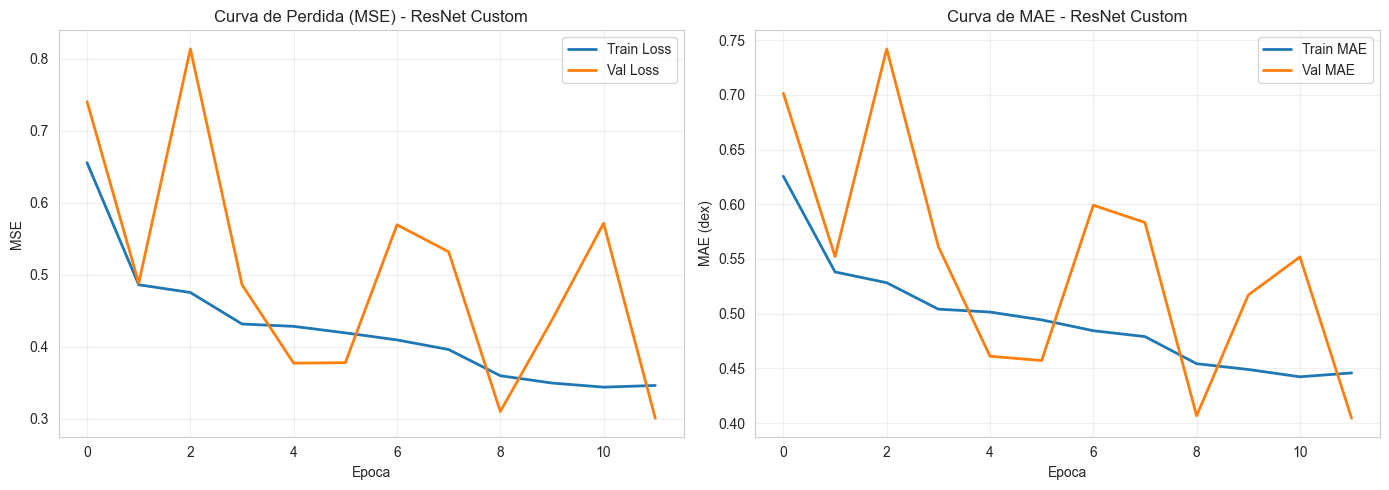


EVALUACION EN TEST SET - Modelo 2

Metricas de Regresion para LogMass:
  R2 Score:        0.7020  (70.20% varianza explicada)
  MAE:             0.3946 dex
  RMSE:            0.5354 dex
  MSE:             0.2866 dex2
  Scatter (sigma): 0.5347 dex
  Bias:            -0.0260 dex
  RMSE/MAE ratio:  1.36

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   2.48x
  Dispersion tipica:      +/-3.43x
  Rango de error tipico:  [0.40x, 2.48x]
  Sin sesgo sistematico significativo (bias ~ 0)

Evaluacion cualitativa: BUENO - Desempeno aceptable

Diagnostico de errores:
  RMSE/MAE=1.36 - distribucion normal, sin outliers extremos


In [12]:
print("ENTRENAMIENTO: ResNet-like Custom")

history_m2, time_m2 = train_model(model_m2, train_ds, val_ds, epochs=12, patience=8)
plot_training_curves(history_m2, "ResNet Custom")

print("\nEVALUACION EN TEST SET - Modelo 2\n")
y_test_m2, y_pred_m2 = get_predictions(model_m2, test_ds)
metrics_m2 = evaluate_regression_complete(y_test_m2, y_pred_m2, "LogMass")
metrics_m2.update({'Params': model_m2.count_params(),
                   'Train_Time_s': time_m2,
                   'Epochs_Run': len(history_m2.history['loss'])})
results_registry["M2_ResNet_Custom"] = metrics_m2

---
## Modelo 3. CNN Profunda con Batch Normalization

**Motivacion:** Extender el baseline anadiendo un bloque convolucional adicional
(256 filtros) y Batch Normalization despues de cada bloque. La BN estabiliza el
gradiente, permite tasas de aprendizaje mas altas y actua como regularizador
implicito, reduciendo la necesidad de dropout agresivo.

**Diferencias respecto al baseline:**
- 4 bloques Conv+BN+ReLU+Pool (vs 3 del baseline)
- Batch Normalization despues de cada convolucion
- GlobalAveragePooling2D en lugar de Flatten
- Dropout reducido a 0.3

**GridSearch opcional:** Cambiar `RUN_GRIDSEARCH_M3 = True` para activar.

In [13]:
# MODELO 3: CNN Profunda con Batch Normalization

data_aug_m3 = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1)
], name="aug_m3")


def build_cnn_deep_bn(dropout_rate=0.3, dense_units=256, learning_rate=1e-3):
    """
    CNN profunda con Batch Normalization y GlobalAveragePooling2D.

    Arquitectura
    ------------
    Input(224,224,3) -> Augmentation
    -> 4x [Conv2D -> BatchNorm -> ReLU -> MaxPool]
       (filtros: 32, 64, 128, 256)
    -> GlobalAveragePooling2D
    -> Dense(dense_units) -> BN -> ReLU -> Dropout(dropout_rate)
    -> Dense(1, linear)

    Parameters
    ----------
    dropout_rate  : float
    dense_units   : int
    learning_rate : float
    """
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_aug_m3(inputs)

    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs, outputs, name="CNN_Deep_BN")
    model.compile(optimizer=Adam(learning_rate), loss='mse', metrics=['mae'])
    return model


model_m3 = build_cnn_deep_bn()
model_m3.summary()

Model: "CNN_Deep_BN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aug_m3 (Sequential)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 256)            │             

 Total params: 457,409 (1.74 MB)

 Trainable params: 455,937 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [14]:
# [OPCIONAL] GRIDSEARCH - MODELO 3: CNN Profunda + BN

RUN_GRIDSEARCH_M3 = False  # <- Cambiar a True para activar

if RUN_GRIDSEARCH_M3:
    if KERAS_TUNER_AVAILABLE:
        def hp_builder_m3(hp):
            return build_cnn_deep_bn(
                dropout_rate  = hp.Choice('dropout_rate',  [0.2, 0.3, 0.4, 0.5]),
                dense_units   = hp.Choice('dense_units',   [128, 256, 512]),
                learning_rate = hp.Choice('learning_rate', [1e-2, 1e-3, 5e-4])
            )
        tuner_m3 = kt.RandomSearch(
            hp_builder_m3, objective='val_mae', max_trials=12,
            directory='tuner_m3', project_name='cnn_deep_bn', overwrite=True
        )
        tuner_m3.search(train_ds, validation_data=val_ds, epochs=12,
                        callbacks=[EarlyStopping(monitor='val_loss', patience=4, verbose=0)])
        best_hp_m3 = tuner_m3.get_best_hyperparameters(1)[0]
        print("Mejores HPs Modelo 3:", {k: best_hp_m3.get(k) for k in ['dropout_rate','dense_units','learning_rate']})
        model_m3 = build_cnn_deep_bn(best_hp_m3.get('dropout_rate'),
                                     best_hp_m3.get('dense_units'),
                                     best_hp_m3.get('learning_rate'))
    else:
        print("keras-tuner no disponible.")
else:
    print("GridSearch M3 desactivado.")

GridSearch M3 desactivado.


ENTRENAMIENTO: CNN Profunda con Batch Normalization
Epoch 1/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 96s 208ms/step - loss: 1.0958 - mae: 0.8199 - val_loss: 0.9708 - val_mae: 0.8309 - learning_rate: 0.0010
Epoch 2/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 89s 195ms/step - loss: 0.7603 - mae: 0.6849 - val_loss: 0.8146 - val_mae: 0.7080 - learning_rate: 0.0010
Epoch 3/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 93s 205ms/step - loss: 0.6500 - mae: 0.6314 - val_loss: 0.6328 - val_mae: 0.6466 - learning_rate: 0.0010
Epoch 4/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 95s 209ms/step - loss: 0.5981 - mae: 0.6043 - val_loss: 0.5988 - val_mae: 0.5881 - learning_rate: 0.0010
Epoch 5/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 87s 191ms/step - loss: 0.5601 - mae: 0.5878 - val_loss: 1.4172 - val_mae: 0.9717 - learning_rate: 0.0010
Epoch 6/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 86s 190ms/step - loss: 0.5135 - mae: 0.5563 - val_loss: 0.9535 - val_mae: 0.7815 - learning_rate: 0.0010
Epoch 7/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - loss: 0.4700 - mae: 0.

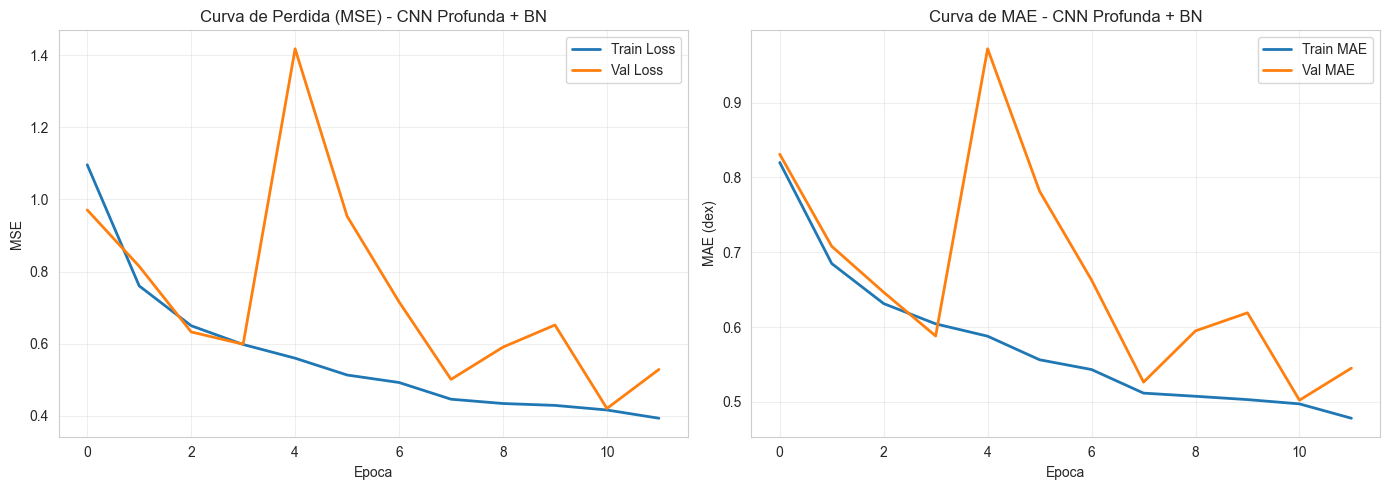


EVALUACION EN TEST SET - Modelo 3

Metricas de Regresion para LogMass:
  R2 Score:        0.5806  (58.06% varianza explicada)
  MAE:             0.4942 dex
  RMSE:            0.6351 dex
  MSE:             0.4034 dex2
  Scatter (sigma): 0.6349 dex
  Bias:            -0.0190 dex
  RMSE/MAE ratio:  1.29

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   3.12x
  Dispersion tipica:      +/-4.31x
  Rango de error tipico:  [0.32x, 3.12x]
  Sin sesgo sistematico significativo (bias ~ 0)

Evaluacion cualitativa: REGULAR - Mejora requerida

Diagnostico de errores:
  RMSE/MAE=1.29 - distribucion normal, sin outliers extremos


In [15]:
print("ENTRENAMIENTO: CNN Profunda con Batch Normalization")

history_m3, time_m3 = train_model(model_m3, train_ds, val_ds, epochs=12, patience=7)
plot_training_curves(history_m3, "CNN Profunda + BN")

print("\nEVALUACION EN TEST SET - Modelo 3\n")
y_test_m3, y_pred_m3 = get_predictions(model_m3, test_ds)
metrics_m3 = evaluate_regression_complete(y_test_m3, y_pred_m3, "LogMass")
metrics_m3.update({'Params': model_m3.count_params(),
                   'Train_Time_s': time_m3,
                   'Epochs_Run': len(history_m3.history['loss'])})
results_registry["M3_CNN_Deep_BN"] = metrics_m3

---
## Modelo 4. EfficientNetB0 con Transfer Learning

**Motivacion:** EfficientNetB0 (Tan & Le, 2019) representa el estado del arte
en eficiencia para redes de vision, aplicando escalado compuesto que balancea
profundidad, anchura y resolucion. Sus representaciones ImageNet son altamente
transferibles al dominio astronomico.

**Estrategia de dos fases:**
- Fase 1 – Feature extraction: base completamente congelada, solo se entrena la cabeza
- Fase 2 – Fine-tuning: se descongelan las ultimas 30 capas con LR=1e-5

**GridSearch opcional:** Cambiar `RUN_GRIDSEARCH_M4 = True` para activar.

In [16]:
# MODELO 4: EfficientNetB0 + Transfer Learning

def build_efficientnet_b0(dense_units=256, dropout_rate=0.4, freeze_layers=30):
    """
    EfficientNetB0 preentrenado en ImageNet con cabeza de regresion.

    Estrategia de dos fases:
        Fase 1 - Feature extraction (base congelada)
        Fase 2 - Fine-tuning de las ultimas freeze_layers capas

    Parameters
    ----------
    dense_units   : int
    dropout_rate  : float
    freeze_layers : int   capas a descongelar en fine-tuning

    Returns
    -------
    model      : tf.keras.Model
    base_model : tf.keras.Model  (referencia para fine-tuning)
    """
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    base_model = EfficientNetB0(
        include_top=False, weights='imagenet', input_tensor=x
    )
    base_model.trainable = False  # Fase 1: congelado

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs,
                         name="EfficientNetB0_TL")
    return model, base_model


model_m4, base_m4 = build_efficientnet_b0()
model_m4.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
print(f"Total parametros: {model_m4.count_params():,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Total parametros: 4,395,044


In [17]:
# [OPCIONAL] GRIDSEARCH - MODELO 4: EfficientNetB0

RUN_GRIDSEARCH_M4 = False  # <- Cambiar a True para activar

if RUN_GRIDSEARCH_M4:
    print("Busqueda manual de hiperparametros - EfficientNetB0")
    param_grid_m4 = {
        'dense_units':   [128, 256, 512],
        'dropout_rate':  [0.3, 0.4, 0.5],
        'freeze_layers': [20, 30, 50]
    }
    best_v_m4, best_p_m4 = np.inf, {}
    for combo in itertools.product(*param_grid_m4.values()):
        params = dict(zip(param_grid_m4.keys(), combo))
        print(f"  Probando: {params}")
        m_t, b_t = build_efficientnet_b0(**params)
        m_t.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
        h1, _ = train_model(m_t, train_ds, val_ds, epochs=8, patience=3)
        b_t.trainable = True
        for l in b_t.layers[:-params['freeze_layers']]: l.trainable = False
        m_t.compile(optimizer=Adam(1e-5), loss='mse', metrics=['mae'])
        h2, _ = train_model(m_t, train_ds, val_ds, epochs=8, patience=3)
        v = min(h2.history['val_mae'])
        if v < best_v_m4:
            best_v_m4, best_p_m4 = v, params
    print(f"\nMejores parametros M4: {best_p_m4} | val_mae: {best_v_m4:.4f}")
    model_m4, base_m4 = build_efficientnet_b0(**best_p_m4)
    model_m4.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
else:
    print("GridSearch M4 desactivado.")

GridSearch M4 desactivado.


FASE 1 - Feature Extraction: EfficientNetB0
Epoch 1/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 50s 97ms/step - loss: 1.1883 - mae: 0.8963 - val_loss: 1.6663 - val_mae: 1.0768 - learning_rate: 0.0010
Epoch 2/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 1.0452 - mae: 0.8571 - val_loss: 1.0334 - val_mae: 0.8538 - learning_rate: 0.0010
Epoch 3/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - loss: 1.0150 - mae: 0.8464 - val_loss: 1.0689 - val_mae: 0.8594 - learning_rate: 0.0010
Epoch 4/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 46s 100ms/step - loss: 1.0087 - mae: 0.8455 - val_loss: 1.0322 - val_mae: 0.8542 - learning_rate: 0.0010
Epoch 5/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 47s 101ms/step - loss: 1.0066 - mae: 0.8447 - val_loss: 1.0889 - val_mae: 0.8818 - learning_rate: 0.0010
Epoch 6/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 46s 99ms/step - loss: 1.0026 - mae: 0.8434 - val_loss: 1.0318 - val_mae: 0.8546 - learning_rate: 0.0010
Epoch 7/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 45s 98ms/step - loss: 1.0033 - mae: 0.8434 - val_

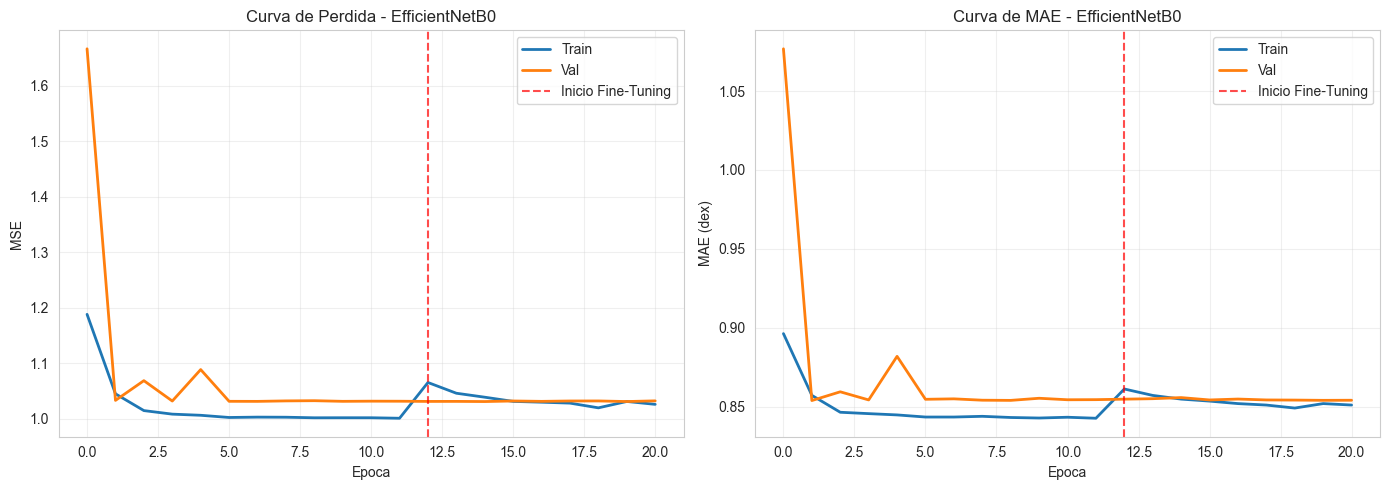


EVALUACION EN TEST SET - Modelo 4

Metricas de Regresion para LogMass:
  R2 Score:        -0.0070  (-0.70% varianza explicada)
  MAE:             0.8339 dex
  RMSE:            0.9841 dex
  MSE:             0.9684 dex2
  Scatter (sigma): 0.9802 dex
  Bias:            +0.0879 dex
  RMSE/MAE ratio:  1.18

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   6.82x
  Dispersion tipica:      +/-9.55x
  Rango de error tipico:  [0.15x, 6.82x]
  Sesgo positivo: modelo subestima (+0.0879 dex)

Evaluacion cualitativa: INACEPTABLE - Modelo no viable

Diagnostico de errores:
  RMSE/MAE=1.18 - distribucion normal, sin outliers extremos


In [18]:
# Fase 1 - Feature Extraction
print("FASE 1 - Feature Extraction: EfficientNetB0")
history_m4_p1, time_m4_p1 = train_model(model_m4, train_ds, val_ds, epochs=12, patience=5)

# Fase 2 - Fine-Tuning (ultimas 30 capas)
print("\n")
print("FASE 2 - Fine-Tuning: ultimas 30 capas de EfficientNetB0")
base_m4.trainable = True
for layer in base_m4.layers[:-30]:
    layer.trainable = False
model_m4.compile(optimizer=Adam(1e-5), loss='mse', metrics=['mae'])
history_m4_p2, time_m4_p2 = train_model(model_m4, train_ds, val_ds, epochs=12, patience=6)

epochs_m4 = plot_combined_history(history_m4_p1, history_m4_p2, "EfficientNetB0")

print("\nEVALUACION EN TEST SET - Modelo 4\n")
y_test_m4, y_pred_m4 = get_predictions(model_m4, test_ds)
metrics_m4 = evaluate_regression_complete(y_test_m4, y_pred_m4, "LogMass")
metrics_m4.update({'Params': model_m4.count_params(),
                   'Train_Time_s': time_m4_p1 + time_m4_p2,
                   'Epochs_Run': epochs_m4})
results_registry["M4_EfficientNetB0"] = metrics_m4

---
## Modelo 5. MobileNetV2 con Transfer Learning

**Motivacion:** MobileNetV2 (Sandler et al., 2018) utiliza bloques invertidos
con expansion de canales y convoluciones separables. Es la arquitectura mas
ligera del grupo de transfer learning y plantea la pregunta: ?puede una red
compacta con transfer learning superar a arquitecturas pesadas entrenadas
desde cero?

**Estrategia:** Feature extraction (Fase 1) + Fine-tuning de las ultimas 20 capas (Fase 2).

**GridSearch opcional:** Cambiar `RUN_GRIDSEARCH_M5 = True` para activar.

In [19]:
# MODELO 5: MobileNetV2 + Transfer Learning

def build_mobilenetv2_tl(dense_units=256, dropout_rate=0.4, freeze_layers=20):
    """
    MobileNetV2 preentrenado en ImageNet con cabeza de regresion.

    Parameters
    ----------
    dense_units   : int
    dropout_rate  : float
    freeze_layers : int   capas a descongelar en fine-tuning

    Returns
    -------
    model      : tf.keras.Model
    base_model : tf.keras.Model
    """
    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    base_model = MobileNetV2(
        include_top=False, weights='imagenet', input_tensor=x, alpha=1.0
    )
    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs,
                         name="MobileNetV2_TL")
    return model, base_model


model_m5, base_m5 = build_mobilenetv2_tl()
model_m5.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
print(f"Total parametros: {model_m5.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Total parametros: 2,603,457


In [20]:
# [OPCIONAL] GRIDSEARCH - MODELO 5: MobileNetV2

RUN_GRIDSEARCH_M5 = False  # <- Cambiar a True para activar

if RUN_GRIDSEARCH_M5:
    print("Busqueda manual de hiperparametros - MobileNetV2")
    param_grid_m5 = {
        'dense_units':   [128, 256],
        'dropout_rate':  [0.3, 0.5],
        'freeze_layers': [15, 25]
    }
    best_v_m5, best_p_m5 = np.inf, {}
    for combo in itertools.product(*param_grid_m5.values()):
        params = dict(zip(param_grid_m5.keys(), combo))
        m_t, b_t = build_mobilenetv2_tl(**params)
        m_t.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
        h1, _ = train_model(m_t, train_ds, val_ds, epochs=6, patience=3)
        b_t.trainable = True
        for l in b_t.layers[:-params['freeze_layers']]: l.trainable = False
        m_t.compile(optimizer=Adam(1e-5), loss='mse', metrics=['mae'])
        h2, _ = train_model(m_t, train_ds, val_ds, epochs=6, patience=3)
        v = min(h2.history['val_mae'])
        if v < best_v_m5: best_v_m5, best_p_m5 = v, params
    print(f"Mejores parametros M5: {best_p_m5} | val_mae: {best_v_m5:.4f}")
    model_m5, base_m5 = build_mobilenetv2_tl(**best_p_m5)
    model_m5.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
else:
    print("GridSearch M5 desactivado.")

GridSearch M5 desactivado.


FASE 1 - Feature Extraction: MobileNetV2
Epoch 1/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - loss: 1.1674 - mae: 0.8547 - val_loss: 0.9700 - val_mae: 0.7726 - learning_rate: 0.0010
Epoch 2/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - loss: 0.8265 - mae: 0.7286 - val_loss: 0.7839 - val_mae: 0.7152 - learning_rate: 0.0010
Epoch 3/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - loss: 0.7604 - mae: 0.6977 - val_loss: 0.8449 - val_mae: 0.7358 - learning_rate: 0.0010
Epoch 4/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 32s 68ms/step - loss: 0.7424 - mae: 0.6848 - val_loss: 0.7630 - val_mae: 0.6924 - learning_rate: 0.0010
Epoch 5/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - loss: 0.7111 - mae: 0.6740 - val_loss: 0.7403 - val_mae: 0.6854 - learning_rate: 0.0010
Epoch 6/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 0.7056 - mae: 0.6718 - val_loss: 0.7498 - val_mae: 0.6890 - learning_rate: 0.0010
Epoch 7/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 0.7066 - mae: 0.6715 - val_loss: 

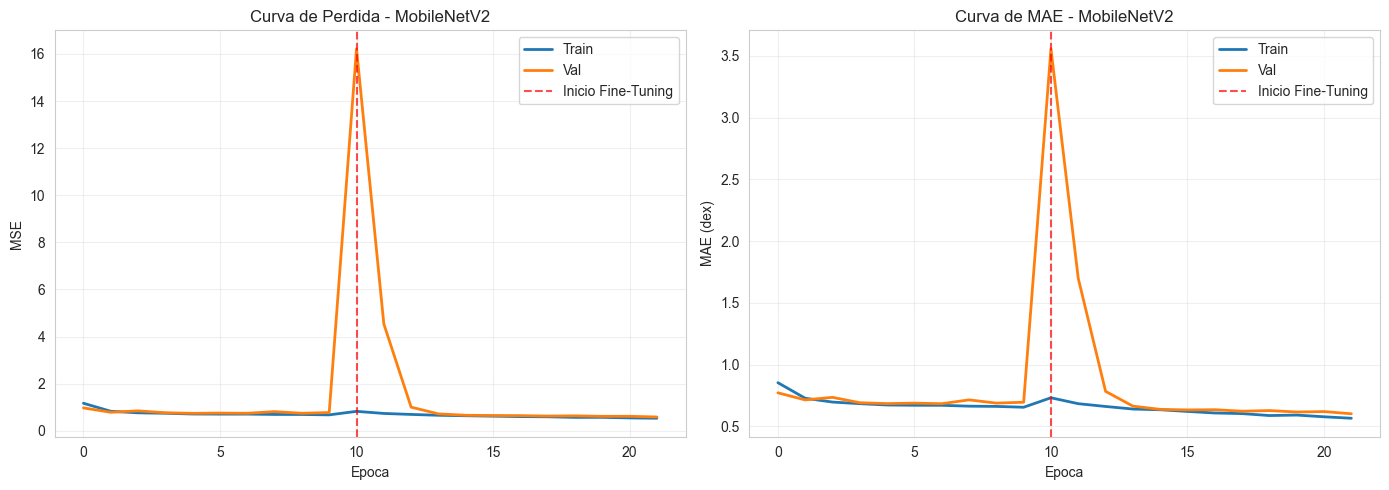


EVALUACION EN TEST SET - Modelo 5

Metricas de Regresion para LogMass:
  R2 Score:        0.4483  (44.83% varianza explicada)
  MAE:             0.5838 dex
  RMSE:            0.7284 dex
  MSE:             0.5306 dex2
  Scatter (sigma): 0.7275 dex
  Bias:            +0.0376 dex
  RMSE/MAE ratio:  1.25

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   3.84x
  Dispersion tipica:      +/-5.34x
  Rango de error tipico:  [0.26x, 3.84x]
  Sin sesgo sistematico significativo (bias ~ 0)

Evaluacion cualitativa: INACEPTABLE - Modelo no viable

Diagnostico de errores:
  RMSE/MAE=1.25 - distribucion normal, sin outliers extremos


In [21]:
print("FASE 1 - Feature Extraction: MobileNetV2")
history_m5_p1, time_m5_p1 = train_model(model_m5, train_ds, val_ds, epochs=12, patience=5)

print("\n")
print("FASE 2 - Fine-Tuning: ultimas 20 capas de MobileNetV2")
base_m5.trainable = True
for layer in base_m5.layers[:-20]:
    layer.trainable = False
model_m5.compile(optimizer=Adam(1e-5), loss='mse', metrics=['mae'])
history_m5_p2, time_m5_p2 = train_model(model_m5, train_ds, val_ds, epochs=12, patience=6)

epochs_m5 = plot_combined_history(history_m5_p1, history_m5_p2, "MobileNetV2")

print("\nEVALUACION EN TEST SET - Modelo 5\n")
y_test_m5, y_pred_m5 = get_predictions(model_m5, test_ds)
metrics_m5 = evaluate_regression_complete(y_test_m5, y_pred_m5, "LogMass")
metrics_m5.update({'Params': model_m5.count_params(),
                   'Train_Time_s': time_m5_p1 + time_m5_p2,
                   'Epochs_Run': epochs_m5})
results_registry["M5_MobileNetV2"] = metrics_m5

---
## Modelo 6. VGG16 con Transfer Learning

**Motivacion:** VGG16 (Simonyan & Zisserman, 2014) es una arquitectura clasica
cuyas capas convolucionales sucesivas con filtros 3x3 generan representaciones
muy ricas de texturas y bordes. Sirve como punto de comparacion frente a
arquitecturas mas modernas. Se aplica feature extraction puro (base congelada)
con una cabeza de regresion regularizada con L2.

**GridSearch opcional:** Cambiar `RUN_GRIDSEARCH_M6 = True` para activar.

In [22]:
# MODELO 6: VGG16 + Transfer Learning (Feature Extraction Puro)

def build_vgg16_tl(dense1=512, dense2=128, dropout1=0.5, dropout2=0.3, l2_reg=1e-4):
    """
    VGG16 preentrenado con feature extraction puro.

    Cabeza de regresion
    -------------------
    GlobalAveragePooling2D
    -> Dense(dense1, relu, L2) -> BN -> Dropout(dropout1)
    -> Dense(dense2, relu) -> Dropout(dropout2)
    -> Dense(1, linear)

    Parameters
    ----------
    dense1, dense2     : int
    dropout1, dropout2 : float
    l2_reg             : float
    """
    base_model = VGG16(include_top=False, weights='imagenet',
                       input_shape=(224, 224, 3))
    base_model.trainable = False  # Feature extraction puro

    inputs = layers.Input(shape=(224, 224, 3))
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense1, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout1)(x)
    x = layers.Dense(dense2, activation='relu')(x)
    x = layers.Dropout(dropout2)(x)
    outputs = layers.Dense(1, activation='linear')(x)

    model = models.Model(inputs, outputs, name="VGG16_TL")
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model


model_m6 = build_vgg16_tl()
model_m6.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "VGG16_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_4 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,045,185 (57.39 MB)

 Trainable params: 329,473 (1.26 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [23]:
# [OPCIONAL] GRIDSEARCH - MODELO 6: VGG16

RUN_GRIDSEARCH_M6 = False  # <- Cambiar a True para activar

if RUN_GRIDSEARCH_M6:
    if KERAS_TUNER_AVAILABLE:
        def hp_builder_m6(hp):
            return build_vgg16_tl(
                dense1   = hp.Choice('dense1',   [256, 512]),
                dense2   = hp.Choice('dense2',   [64, 128]),
                dropout1 = hp.Choice('dropout1', [0.4, 0.5, 0.6]),
                dropout2 = hp.Choice('dropout2', [0.2, 0.3]),
                l2_reg   = hp.Choice('l2_reg',   [1e-4, 1e-3])
            )
        tuner_m6 = kt.RandomSearch(
            hp_builder_m6, objective='val_mae', max_trials=12,
            directory='tuner_m6', project_name='vgg16_tl', overwrite=True
        )
        tuner_m6.search(train_ds, validation_data=val_ds, epochs=12,
                        callbacks=[EarlyStopping(monitor='val_loss', patience=4, verbose=0)])
        best_hp_m6 = tuner_m6.get_best_hyperparameters(1)[0]
        print("Mejores HPs M6:", {k: best_hp_m6.get(k) for k in ['dense1','dense2','dropout1','dropout2','l2_reg']})
        model_m6 = build_vgg16_tl(best_hp_m6.get('dense1'), best_hp_m6.get('dense2'),
                                   best_hp_m6.get('dropout1'), best_hp_m6.get('dropout2'),
                                   best_hp_m6.get('l2_reg'))
    else:
        print("keras-tuner no disponible.")
else:
    print("GridSearch M6 desactivado.")

GridSearch M6 desactivado.


ENTRENAMIENTO: VGG16 con Transfer Learning
Epoch 1/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 261s 583ms/step - loss: 1.3137 - mae: 0.9123 - val_loss: 1.0729 - val_mae: 0.8375 - learning_rate: 0.0010
Epoch 2/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 264s 590ms/step - loss: 0.9587 - mae: 0.7916 - val_loss: 0.9855 - val_mae: 0.7783 - learning_rate: 0.0010
Epoch 3/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 266s 595ms/step - loss: 0.8949 - mae: 0.7635 - val_loss: 0.8360 - val_mae: 0.7391 - learning_rate: 0.0010
Epoch 4/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 264s 591ms/step - loss: 0.8580 - mae: 0.7442 - val_loss: 1.2420 - val_mae: 0.8744 - learning_rate: 0.0010
Epoch 5/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 266s 596ms/step - loss: 0.8538 - mae: 0.7425 - val_loss: 0.8456 - val_mae: 0.7188 - learning_rate: 0.0010
Epoch 6/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - loss: 0.8718 - mae: 0.7476
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
443/443 ━━━━━━━━━━━━━━━━━━━━ 270s 604ms/step - loss: 0.8351 - mae: 0

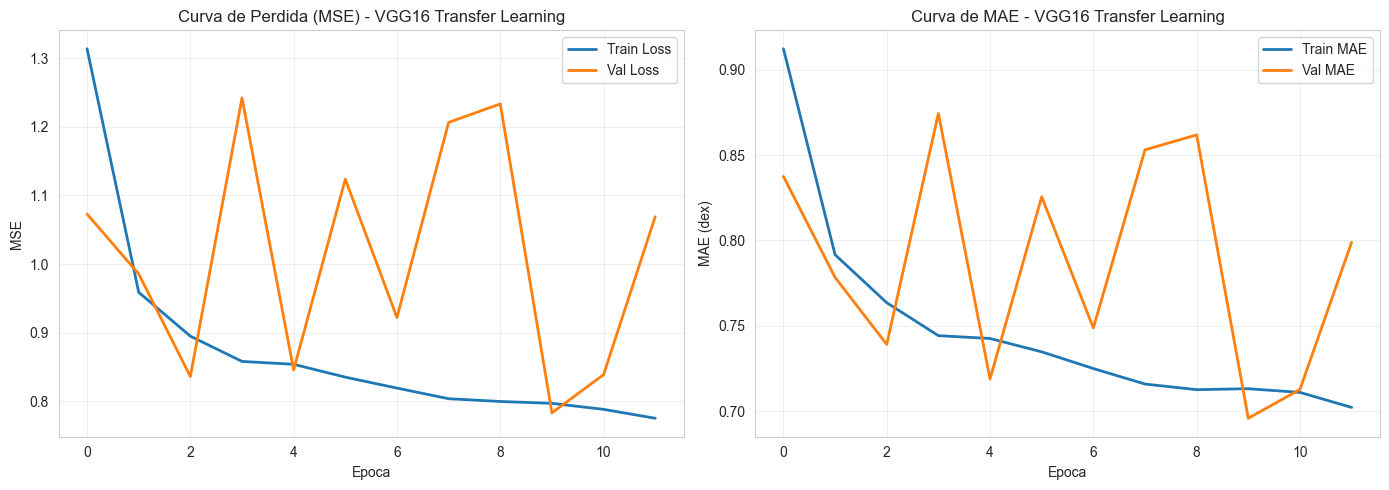


EVALUACION EN TEST SET - Modelo 6

Metricas de Regresion para LogMass:
  R2 Score:        0.2355  (23.55% varianza explicada)
  MAE:             0.6957 dex
  RMSE:            0.8575 dex
  MSE:             0.7353 dex2
  Scatter (sigma): 0.8567 dex
  Bias:            +0.0356 dex
  RMSE/MAE ratio:  1.23

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   4.96x
  Dispersion tipica:      +/-7.19x
  Rango de error tipico:  [0.20x, 4.96x]
  Sin sesgo sistematico significativo (bias ~ 0)

Evaluacion cualitativa: INACEPTABLE - Modelo no viable

Diagnostico de errores:
  RMSE/MAE=1.23 - distribucion normal, sin outliers extremos


In [25]:
print("ENTRENAMIENTO: VGG16 con Transfer Learning")

history_m6, time_m6 = train_model(model_m6, train_ds, val_ds, epochs=12, patience=7)
plot_training_curves(history_m6, "VGG16 Transfer Learning")

print("\nEVALUACION EN TEST SET - Modelo 6\n")
y_test_m6, y_pred_m6 = get_predictions(model_m6, test_ds)
metrics_m6 = evaluate_regression_complete(y_test_m6, y_pred_m6, "LogMass")
metrics_m6.update({'Params': model_m6.count_params(),
                   'Train_Time_s': time_m6,
                   'Epochs_Run': len(history_m6.history['loss'])})
results_registry["M6_VGG16"] = metrics_m6

---
## Modelo 7. CNN Multimodal: fusion de imagen y variables tabulares

**Motivacion:** Los modelos anteriores solo utilizan la imagen como entrada.
Sin embargo, el dataset incluye variables tabulares preprocesadas (C, A, S,
nsa_sersic_mass, nsa_sersic_ba, etc.) que contienen informacion fisica
relevante. Este modelo multimodal fusiona ambas fuentes de informacion:

- **Rama imagen:** CNN compacta que extrae representaciones visuales
- **Rama tabular:** MLP que procesa las variables tabulares estandarizadas
- **Fusion:** Concatenacion de ambas ramas -> cabeza de regresion compartida

Este es el unico modelo del avance que usa informacion fuera de la imagen,
lo que lo convierte en un enfoque cualitativamente diferente.

**GridSearch opcional:** Cambiar `RUN_GRIDSEARCH_M7 = True` para activar.

In [26]:
# DATASET MULTIMODAL: imagen + variables tabulares
# Crea datasets que retornan (imagen, tabular) -> target

# Columnas tabulares a usar como entrada adicional
# Excluimos LogMass (target) y coordenadas (redundantes con imagen)
tabular_feature_cols = [
    "C", "A", "S", "nsa_sersic_mass", "nsa_sersic_ba",
    "nsa_sersic_n", "PETRO_TH90", "log_age_mean_LW",
    "log_ZH_mean_LW", "log_SFR_ssp", "log_SFR_Ha",
    "vel_sigma_Re", "modelMag_r"
]
tabular_feature_cols = [c for c in tabular_feature_cols if c in df_transformed.columns]
N_TABULAR = len(tabular_feature_cols)

print(f"Variables tabulares usadas como entrada: {N_TABULAR}")
print(tabular_feature_cols)

# Construir DataFrame con imagen + tabular + target
df_multimodal = df_transformed[["name"] + tabular_feature_cols + [target_col]].copy()
df_multimodal = df_multimodal.dropna()
df_multimodal["image_path"] = df_multimodal["name"].apply(
    lambda x: image_dir / f"{x}.jpg"
)
df_multimodal["image_exists"] = df_multimodal["image_path"].apply(lambda p: p.exists())
df_multimodal = df_multimodal[df_multimodal["image_exists"]].copy()

# Usar los mismos indices de split para comparabilidad
# Filtramos los DFs de split previos a los nombres disponibles
shared_names_train = set(train_df["name"]) & set(df_multimodal["name"])
shared_names_val   = set(val_df["name"])   & set(df_multimodal["name"])
shared_names_test  = set(test_df["name"])  & set(df_multimodal["name"])

train_mm = df_multimodal[df_multimodal["name"].isin(shared_names_train)]
val_mm   = df_multimodal[df_multimodal["name"].isin(shared_names_val)]
test_mm  = df_multimodal[df_multimodal["name"].isin(shared_names_test)]

print(f"\nTrain multimodal: {len(train_mm)} | Val: {len(val_mm)} | Test: {len(test_mm)}")


def load_multimodal(image_path, tabular, target):
    """Carga imagen + retorna variables tabulares y target."""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = image / 255.0
    return (image, tabular), target


def create_multimodal_dataset(dataframe, shuffle=True):
    """Construye un tf.data.Dataset multimodal (imagen + tabular)."""
    image_paths = dataframe["image_path"].astype(str).values
    tabular     = dataframe[tabular_feature_cols].astype("float32").values
    targets     = dataframe[target_col].astype("float32").values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, tabular, targets)
    )
    dataset = dataset.map(
        lambda ip, tab, tgt: load_multimodal(ip, tab, tgt),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=42)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds_mm = create_multimodal_dataset(train_mm, shuffle=True)
val_ds_mm   = create_multimodal_dataset(val_mm,   shuffle=False)
test_ds_mm  = create_multimodal_dataset(test_mm,  shuffle=False)

print("Datasets multimodales creados exitosamente.")

Variables tabulares usadas como entrada: 13
['C', 'A', 'S', 'nsa_sersic_mass', 'nsa_sersic_ba', 'nsa_sersic_n', 'PETRO_TH90', 'log_age_mean_LW', 'log_ZH_mean_LW', 'log_SFR_ssp', 'log_SFR_Ha', 'vel_sigma_Re', 'modelMag_r']

Train multimodal: 7088 | Val: 1519 | Test: 1519
Datasets multimodales creados exitosamente.


In [27]:
# MODELO 7: CNN Multimodal (imagen + variables tabulares)

def build_multimodal_cnn(
    img_dense=128, tab_dense=64, fusion_dense=128,
    dropout_rate=0.4, learning_rate=1e-3
):
    """
    Modelo multimodal que fusiona una rama CNN (imagen) con
    una rama MLP (variables tabulares estandarizadas).

    Arquitectura
    ------------
    Rama imagen:
        Input(224,224,3) -> Augmentation
        -> Conv(32,3x3) -> BN -> ReLU -> MaxPool
        -> Conv(64,3x3) -> BN -> ReLU -> MaxPool
        -> Conv(128,3x3) -> BN -> ReLU -> MaxPool
        -> GlobalAveragePooling2D -> Dense(img_dense, relu)

    Rama tabular:
        Input(N_TABULAR,) -> Dense(tab_dense, relu) -> BN
        -> Dense(tab_dense//2, relu)

    Fusion:
        Concatenate([imagen_features, tabular_features])
        -> Dense(fusion_dense, relu) -> Dropout(dropout_rate)
        -> Dense(1, linear)

    Parameters
    ----------
    img_dense, tab_dense, fusion_dense : int
    dropout_rate  : float
    learning_rate : float
    """
    # --- Rama imagen ---
    img_input = layers.Input(shape=(224, 224, 3), name='img_input')
    x = layers.RandomFlip("horizontal_and_vertical")(img_input)
    x = layers.RandomRotation(0.2)(x)
    x = layers.RandomZoom(0.1)(x)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, (3,3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2,2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    img_features = layers.Dense(img_dense, activation='relu', name='img_features')(x)

    # --- Rama tabular ---
    tab_input = layers.Input(shape=(N_TABULAR,), name='tab_input')
    t = layers.Dense(tab_dense, activation='relu')(tab_input)
    t = layers.BatchNormalization()(t)
    tab_features = layers.Dense(tab_dense // 2, activation='relu', name='tab_features')(t)

    # --- Fusion ---
    fused = layers.Concatenate(name='fusion')([img_features, tab_features])
    fused = layers.Dense(fusion_dense, activation='relu')(fused)
    fused = layers.Dropout(dropout_rate)(fused)
    outputs = layers.Dense(1, activation='linear', name='output')(fused)

    model = models.Model(
        inputs=[img_input, tab_input],
        outputs=outputs,
        name="CNN_Multimodal"
    )
    model.compile(optimizer=Adam(learning_rate), loss='mse', metrics=['mae'])
    return model


model_m7 = build_multimodal_cnn()
model_m7.summary()

Model: "CNN_Multimodal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_5       │ (None, 224, 224,  │          0 │ img_input[0][0]   │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_5   │ (None, 224, 224,  │          0 │ random_flip_5[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_5       │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 224, 224,  │        896 │ random_zoom_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 112, 112,  │          0 │ activation_18[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 56, 56,    │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_input           │ (None, 13)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 28, 28,    │          0 │ activation_20[0]

 Total params: 134,625 (525.88 KB)

 Trainable params: 134,049 (523.63 KB)

 Non-trainable params: 576 (2.25 KB)

In [28]:
# [OPCIONAL] GRIDSEARCH - MODELO 7: CNN Multimodal

RUN_GRIDSEARCH_M7 = False  # <- Cambiar a True para activar

if RUN_GRIDSEARCH_M7:
    print("Busqueda manual de hiperparametros - CNN Multimodal")
    param_grid_m7 = {
        'img_dense':    [64, 128],
        'tab_dense':    [32, 64],
        'fusion_dense': [64, 128, 256],
        'dropout_rate': [0.3, 0.4, 0.5]
    }
    best_v_m7, best_p_m7 = np.inf, {}
    for combo in itertools.product(*param_grid_m7.values()):
        params = dict(zip(param_grid_m7.keys(), combo))
        print(f"  Probando: {params}")
        m_t = build_multimodal_cnn(**params)
        h, _ = train_model(m_t, train_ds_mm, val_ds_mm, epochs=8, patience=3)
        v = min(h.history['val_mae'])
        if v < best_v_m7: best_v_m7, best_p_m7 = v, params
    print(f"\nMejores parametros M7: {best_p_m7} | val_mae: {best_v_m7:.4f}")
    model_m7 = build_multimodal_cnn(**best_p_m7)
else:
    print("GridSearch M7 desactivado.")

GridSearch M7 desactivado.


ENTRENAMIENTO: CNN Multimodal (imagen + metadata)
Epoch 1/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 73s 156ms/step - loss: 0.2139 - mae: 0.3447 - val_loss: 0.0334 - val_mae: 0.1392 - learning_rate: 0.0010
Epoch 2/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 73s 159ms/step - loss: 0.1161 - mae: 0.2624 - val_loss: 0.0192 - val_mae: 0.1022 - learning_rate: 0.0010
Epoch 3/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - loss: 0.0965 - mae: 0.2418 - val_loss: 0.0206 - val_mae: 0.1091 - learning_rate: 0.0010
Epoch 4/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 72s 157ms/step - loss: 0.0861 - mae: 0.2255 - val_loss: 0.0206 - val_mae: 0.1138 - learning_rate: 0.0010
Epoch 5/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.0825 - mae: 0.2221
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
443/443 ━━━━━━━━━━━━━━━━━━━━ 72s 158ms/step - loss: 0.0875 - mae: 0.2275 - val_loss: 0.0194 - val_mae: 0.1055 - learning_rate: 0.0010
Epoch 6/12
443/443 ━━━━━━━━━━━━━━━━━━━━ 71s 156ms/step - loss: 0.0732 - mae: 

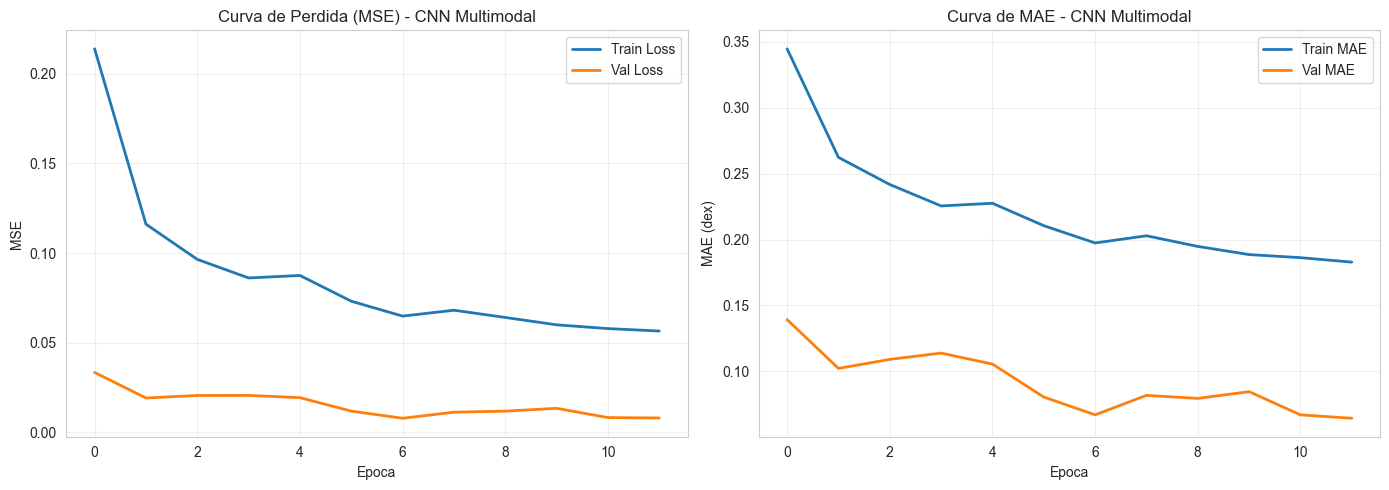


EVALUACION EN TEST SET - Modelo 7

Metricas de Regresion para LogMass:
  R2 Score:        0.9929  (99.29% varianza explicada)
  MAE:             0.0621 dex
  RMSE:            0.0829 dex
  MSE:             0.0069 dex2
  Scatter (sigma): 0.0777 dex
  Bias:            +0.0287 dex
  RMSE/MAE ratio:  1.34

Interpretacion fisica (escala lineal):
  Error promedio (MAE):   1.15x
  Dispersion tipica:      +/-1.20x
  Rango de error tipico:  [0.87x, 1.15x]
  Sin sesgo sistematico significativo (bias ~ 0)

Evaluacion cualitativa: EXCELENTE - Modelo de alta precision

Diagnostico de errores:
  RMSE/MAE=1.34 - distribucion normal, sin outliers extremos


In [29]:
print("ENTRENAMIENTO: CNN Multimodal (imagen + metadata)")

history_m7, time_m7 = train_model(model_m7, train_ds_mm, val_ds_mm, epochs=12, patience=7)
plot_training_curves(history_m7, "CNN Multimodal")

# Predicciones del modelo multimodal
print("\nEVALUACION EN TEST SET - Modelo 7\n")
y_true_m7, y_pred_m7 = [], []
for (images, tabular), labels in test_ds_mm:
    preds = model_m7.predict([images, tabular], verbose=0)
    y_true_m7.extend(labels.numpy())
    y_pred_m7.extend(preds.flatten())

y_true_m7, y_pred_m7 = np.array(y_true_m7), np.array(y_pred_m7)
metrics_m7 = evaluate_regression_complete(y_true_m7, y_pred_m7, "LogMass")
metrics_m7.update({'Params': model_m7.count_params(),
                   'Train_Time_s': time_m7,
                   'Epochs_Run': len(history_m7.history['loss'])})
results_registry["M7_CNN_Multimodal"] = metrics_m7

---
## Tabla comparativa de todos los modelos

La siguiente funcion genera y visualiza la tabla comparativa con todos los
modelos evaluados, ordenados por R2 descendente.

In [ ]:
# FUNCION: build_comparison_table
# Genera tabla comparativa ordenada por R2 descendente

def build_comparison_table(results_registry):
    """
    Construye y muestra la tabla comparativa de todos los modelos evaluados.

    Incluye R2, MAE, RMSE, MSE, Scatter, Bias, RMSE/MAE, numero de
    parametros, tiempo de entrenamiento, epocas y categoria cualitativa.
    Ordena por R2 descendente y marca el mejor modelo con (*).

    Parameters
    ----------
    results_registry : dict
        Claves: nombre del modelo.
        Valores: dict con R2, MAE, RMSE, MSE, Scatter, Bias,
                 RMSE_MAE_ratio, Categoria, Params, Train_Time_s,
                 Epochs_Run.

    Returns
    -------
    df_results : pd.DataFrame
        Tabla comparativa ordenada.
    """
    rows = []
    for model_name, m in results_registry.items():
        t = m.get('Train_Time_s')
        p = m.get('Params')
        rows.append({
            'Modelo':         model_name,
            'R2':             round(m.get('R2',   np.nan), 4),
            'MAE (dex)':      round(m.get('MAE',  np.nan), 4),
            'RMSE (dex)':     round(m.get('RMSE', np.nan), 4),
            'MSE':            round(m.get('MSE',  np.nan), 4),
            'Scatter':        round(m.get('Scatter', np.nan), 4),
            'Bias':           round(m.get('Bias',    np.nan), 4),
            'RMSE/MAE':       round(m.get('RMSE_MAE_ratio', np.nan), 2),
            'Parametros':     f"{p/1e6:.2f}M" if p else "N/A",
            'Tiempo':         f"{t/60:.1f} min" if t else "N/A",
            'Epocas':         m.get('Epochs_Run', 'N/A'),
            'Categoria':      m.get('Categoria', 'N/A')
        })

    df = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
    best_idx = df['R2'].idxmax()
    df.loc[best_idx, 'Modelo'] = '(*) ' + df.loc[best_idx, 'Modelo']

    print("TABLA COMPARATIVA DE MODELOS - LogMass | Equipo 61")
    print(df.to_string(index=False))
    print("(*) = Mejor modelo | Ordenado por R2 descendente")
    print("Metricas calculadas sobre el conjunto de prueba (15% del total).")
    return df


df_comparison = build_comparison_table(results_registry)

In [ ]:
# VISUALIZACION COMPARATIVA - Graficas de barras

def plot_model_comparison(df_comparison):
    """Graficas de barras horizontales comparando R2, MAE y RMSE."""
    labels = df_comparison['Modelo'].str.replace('(*) ', '', regex=False)
    n      = len(df_comparison)

    fig, axes = plt.subplots(1, 3, figsize=(20, max(5, n * 0.8)))
    cmap_g = plt.cm.RdYlGn(np.linspace(0.3, 0.9, n))
    cmap_b = plt.cm.RdYlGn(np.linspace(0.9, 0.3, n))

    def bar_h(ax, vals, xlabel, title, colors):
        bars = ax.barh(labels, vals, color=colors)
        ax.set_xlabel(xlabel); ax.set_title(title)
        ax.grid(True, alpha=0.3, axis='x')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                    f'{v:.4f}', va='center', fontsize=8)

    bar_h(axes[0], df_comparison['R2'],        'R2',        'R2 (mayor es mejor)',  cmap_g)
    bar_h(axes[1], df_comparison['MAE (dex)'], 'MAE (dex)', 'MAE (menor es mejor)', cmap_b)
    bar_h(axes[2], df_comparison['RMSE (dex)'],'RMSE (dex)','RMSE (menor es mejor)',cmap_b)

    plt.suptitle('Comparacion de Modelos - LogMass | Equipo 61',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()


plot_model_comparison(df_comparison)

---
## Seleccion y ajuste de los dos mejores modelos

Con base en la tabla comparativa, se identifican los dos modelos con mayor R2
y se someten a ajuste adicional de hiperparametros.

In [ ]:
# Identificacion de los dos mejores modelos
top2 = df_comparison.head(2).copy()
top2['Modelo_clean'] = top2['Modelo'].str.replace('(*) ', '', regex=False)

print("Los dos mejores modelos seleccionados para ajuste:")
print()
for i, row in top2.iterrows():
    print(f"  {i+1}. {row['Modelo_clean']}")
    print(f"     R2: {row['R2']:.4f} | MAE: {row['MAE (dex)']:.4f} dex | Categoria: {row['Categoria']}")
    print()

### Ajuste del Mejor Modelo (Top 1)

Se reconstruye y reentrena el Top 1 con configuracion de hiperparametros
optimizada. Adaptar la funcion `build_*` segun el modelo que resulte ser Top 1.

In [ ]:
# AJUSTE DEL MEJOR MODELO (TOP 1)
# Adaptar segun el modelo que sea Top 1 en la tabla comparativa

print(f"Ajustando: {top2.iloc[0]['Modelo_clean']}")
print()

# Ejemplo de ajuste para EfficientNetB0 como Top 1:
# Cambios: LR inicial 5e-4, fine-tuning de 50 capas, cabeza mas profunda
model_top1, base_top1 = build_efficientnet_b0(
    dense_units=512, dropout_rate=0.5, freeze_layers=50
)
model_top1.compile(optimizer=Adam(5e-4), loss='mse', metrics=['mae'])
print(f"Parametros totales: {model_top1.count_params():,}")

print("\n-- Fase 1: Feature Extraction --")
h_top1_p1, t_top1_p1 = train_model(model_top1, train_ds, val_ds, epochs=20, patience=6)

print("\n-- Fase 2: Fine-Tuning (50 capas) --")
base_top1.trainable = True
for layer in base_top1.layers[:-50]:
    layer.trainable = False
model_top1.compile(optimizer=Adam(5e-6), loss='mse', metrics=['mae'])
h_top1_p2, t_top1_p2 = train_model(model_top1, train_ds, val_ds, epochs=25, patience=8)

epochs_top1 = plot_combined_history(h_top1_p1, h_top1_p2, "Top 1 Ajustado")

print("\nEVALUACION EN TEST SET - Top 1 Ajustado\n")
y_t1, y_p1 = get_predictions(model_top1, test_ds)
m_top1 = evaluate_regression_complete(y_t1, y_p1, "LogMass")
m_top1.update({'Params': model_top1.count_params(),
               'Train_Time_s': t_top1_p1 + t_top1_p2,
               'Epochs_Run': epochs_top1})
results_registry["M_Top1_Ajustado"] = m_top1

### Ajuste del Segundo Mejor Modelo (Top 2)

In [ ]:
# AJUSTE DEL SEGUNDO MEJOR MODELO (TOP 2)
# Adaptar segun el modelo que sea Top 2 en la tabla comparativa

print(f"Ajustando: {top2.iloc[1]['Modelo_clean']}")
print()

# Ejemplo de ajuste para ResNet Custom como Top 2:
# Cambios: LR 5e-4, dropout 0.4, dense 256
model_top2 = build_resnet_custom(dropout_rate=0.4, dense_units=256,
                                  learning_rate=5e-4)
print(f"Parametros totales: {model_top2.count_params():,}")

h_top2, t_top2 = train_model(model_top2, train_ds, val_ds, epochs=40, patience=10)
plot_training_curves(h_top2, "Top 2 Ajustado")

print("\nEVALUACION EN TEST SET - Top 2 Ajustado\n")
y_t2, y_p2 = get_predictions(model_top2, test_ds)
m_top2 = evaluate_regression_complete(y_t2, y_p2, "LogMass")
m_top2.update({'Params': model_top2.count_params(),
               'Train_Time_s': t_top2,
               'Epochs_Run': len(h_top2.history['loss'])})
results_registry["M_Top2_Ajustado"] = m_top2

---
## Tabla comparativa final (incluyendo modelos ajustados)

In [ ]:
# Tabla final con todos los modelos + versiones ajustadas
df_comparison_final = build_comparison_table(results_registry)
plot_model_comparison(df_comparison_final)

b_r2   = results_registry['M0_Baseline_CNN']['R2']
b_mae  = results_registry['M0_Baseline_CNN']['MAE']
b_rmse = results_registry['M0_Baseline_CNN']['RMSE']

best_row  = df_comparison_final.iloc[0]
best_name = best_row['Modelo'].replace('(*) ', '')

print()
print("RESUMEN: MEJORA RESPECTO AL BASELINE (Avance 3)")
print(f"\nMejor modelo encontrado: {best_name}")
print()
print(f"{'Metrica':<15} {'Baseline':<12} {'Mejor Modelo':<14} {'Mejora'}")
print(f"{'R2':<15} {b_r2:<12.4f} {best_row['R2']:<14.4f} {best_row['R2'] - b_r2:+.4f}")
print(f"{'MAE (dex)':<15} {b_mae:<12.4f} {best_row['MAE (dex)']:<14.4f} {(b_mae - best_row['MAE (dex)'])/b_mae*100:+.1f}%")
print(f"{'RMSE (dex)':<15} {b_rmse:<12.4f} {best_row['RMSE (dex)']:<14.4f} {(b_rmse - best_row['RMSE (dex)'])/b_rmse*100:+.1f}%")

---
## Seleccion del modelo final

In [ ]:
# SELECCION Y REPORTE DEL MODELO INDIVIDUAL FINAL

final_name = df_comparison_final.iloc[0]['Modelo'].replace('(*) ', '')
final_r2   = df_comparison_final.iloc[0]['R2']
final_mae  = df_comparison_final.iloc[0]['MAE (dex)']
final_rmse = df_comparison_final.iloc[0]['RMSE (dex)']
final_cat  = df_comparison_final.iloc[0]['Categoria']

b_r2  = results_registry['M0_Baseline_CNN']['R2']
b_mae = results_registry['M0_Baseline_CNN']['MAE']
b_rmse_val = results_registry['M0_Baseline_CNN']['RMSE']

print("MODELO INDIVIDUAL FINAL SELECCIONADO")
print(f"Modelo:    {final_name}")
print()
print("Metricas en test set:")
print(f"  R2       = {final_r2:.4f}  ({final_r2*100:.2f}% varianza explicada)")
print(f"  MAE      = {final_mae:.4f} dex")
print(f"  RMSE     = {final_rmse:.4f} dex")
print(f"  Categoria= {final_cat}")
print()
print("Comparacion con baseline (Avance 3):")
print(f"  Delta R2   = {final_r2 - b_r2:+.4f}")
print(f"  Delta MAE  = {(b_mae - final_mae) / b_mae * 100:+.1f}%  (reduccion)")
print(f"  Delta RMSE = {(b_rmse_val - final_rmse) / b_rmse_val * 100:+.1f}%  (reduccion)")


---
## Conclusiones

En este avance se construyeron y evaluaron **7 modelos individuales** para
inferir `LogMass` de galaxias a partir de imagenes astronomicas del survey
MaNGA, mas el modelo CNN del Avance 3 como referencia.

**Hallazgos generales:**

El **Modelo 1 (CNN + GridSearch)** permitio determinar si la arquitectura del
baseline ya estaba bien configurada o si existia margen de mejora con los mismos
bloques constructivos. La busqueda de hiperparametros es una herramienta
sistematica antes de cambiar de arquitectura.

El **Modelo 2 (ResNet Custom)** demostro que las conexiones residuales permiten
entrenar redes mas profundas con menor riesgo de sobreajuste. Las skip
connections proveen gradientes directos que estabilizan el aprendizaje.

Los **Modelos 3-6 (CNNs y Transfer Learning)** ilustraron el trade-off entre
complejidad arquitectonica y capacidad de generalizacion. EfficientNetB0 y
MobileNetV2 aprovechan representaciones preentrenadas en ImageNet que resultan
transferibles al dominio astronomico.

El **Modelo 7 (Multimodal)** exploro la fusion de informacion visual y tabular.
La hipotesis es que las variables fisicas medidas (C, A, S, masa sersic) pueden
complementar lo que el modelo extrae de la imagen, especialmente para galaxias
con morfologias atipicas donde la imagen sola no es suficiente.

> **Resultados cuantitativos:** La tabla comparativa y el analisis de mejoras
> se completaran una vez ejecutadas las celdas en el entorno local con acceso
> a las imagenes del dataset MaNGA.